# Alocação de exames laboratoriais em surtos de arbovirose com aprendizado por reforço

**Apresentação para os orientadores**: o que construímos, como o agente é treinado e o que os resultados mostram.

Roteiro:
1. O problema
2. O ambiente de decisão: epidemia, geografia, casos, ações, recompensa, observação
3. Um episódio visto de perto
4. O agente: arquitetura e crédito por caso
5. Conjuntos de treino e protocolo de avaliação
6. Resultados
   - 6.1 Ambiente completo, no Rio
   - 6.2 Transferência entre geografias
   - 6.3 O defeito do simulador e a correção
   - 6.4 O que o agente aprendeu, caso a caso
   - 6.5 O 2º exame é sempre ótimo?
   - 6.6 Sensibilidade aos parâmetros simulados
   - 6.7 Confirmação em surtos novos
7. Conclusões e próximos passos

> Todas as células usam resultados já salvos em `results/`: o notebook roda em poucos minutos e não retreina nada. Os comandos que geram cada resultado estão indicados em cada seção.

In [1]:
import os, sys, glob, json
from pathlib import Path

RAIZ = Path.cwd()
while not (RAIZ / "pyproject.toml").exists():
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from IPython.display import Image, display, Markdown

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
AZUL, LARANJA, VERDE, CINZA = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#eeeeee", "axes.titlelocation": "left", "figure.dpi": 110})
AVAL = RAIZ / "results" / "v6_avaliacao"
V7 = AVAL / "v7"                      # resultados finais: ambiente corrigido, 5 sementes, surtos 3001-3030
CONFIRMA = AVAL / "v7_confirmacao"    # os mesmos, em 30 surtos novos (4001-4030)
print("raiz do projeto:", RAIZ)

raiz do projeto: C:\Users\segun\Documents\GitHub\Dengue_Diagnostics


## 1. O problema

Quando dengue e chikungunya circulam juntas, a triagem clínica erra muito: os quadros se parecem, e parte dos suspeitos não tem nenhuma das duas. O exame (RT-PCR) resolve, mas **não dá para testar todo mundo** num surto. A pergunta é **quem testar, com qual exame e quando** — uma decisão sequencial tomada em *tempo de epidemia*:

- os suspeitos chegam dia a dia;
- o laudo volta **5 dias** depois, e o caso volta ao decisor com o resultado em mãos;
- centenas de casos ficam abertos ao mesmo tempo.

Modelamos isso como um processo de decisão de Markov num simulador ancorado em dados de vigilância (Rio de Janeiro e Recife) e treinamos agentes de aprendizado por reforço (PPO) para decidir caso a caso.

## 2. O ambiente de decisão

O ambiente segue a interface Gymnasium. Todos os parâmetros estão em arquivos YAML versionados; o ambiente de referência é `experiments/configs/env/kriging_v9.yaml`, e os cenários do experimento v6 (`cenario_*.yaml`, `teste_*.yaml`) só mudam a geografia.

In [2]:
cfg = yaml.safe_load(open("experiments/configs/env/kriging_v9.yaml", encoding="utf-8"))
env_cfg = cfg["env"]
chaves = {
    "size": "grid do mundo (células)", "epilength": "duração do episódio (dias)", "epi_model": "modelo temporal",
    "initial_infected_fraction": "fração inicial de infectados", "lab_delay_days": "atraso do laudo (dias)",
    "clinical_specificity": "acerto do médico (sorteado por episódio)", "other_prevalence": "fração de suspeitos que não são arbovirose",
    "lab_sensitivity": "sensibilidade do exame", "lab_specificity": "especificidade do exame",
    "lab_inconclusive_prob": "prob. de laudo inconclusivo", "max_case_revisits": "máx. de retornos do caso",
    "test_cost": "custo de um exame", "epi_confirm_cost": "custo da confirmação epidemiológica",
    "epi_radius": "raio da confirmação epidemiológica (células)", "shaping_conclude_bonus": "bônus por concluir caso investigado",
    "penalty_unresolved": "penalidade por caso não resolvido",
}
pd.DataFrame([(k, env_cfg.get(k), d) for k, d in chaves.items()], columns=["parâmetro", "valor", "significado"])

,parâmetro,valor,significado
0,size,400,grid do mundo (células)
1,epilength,300,duração do episódio (dias)
2,epi_model,seir,modelo temporal
3,initial_infected_fraction,0.01,fração inicial de infectados
4,lab_delay_days,5,atraso do laudo (dias)
5,clinical_specificity,"[0.5, 0.95]",acerto do médico (sorteado por episódio)
6,other_prevalence,0.25,fração de suspeitos que não são arbovirose
7,lab_sensitivity,0.95,sensibilidade do exame
8,lab_specificity,0.98,especificidade do exame
9,lab_inconclusive_prob,0.02,prob. de laudo inconclusivo


### 2.1 Dinâmica epidêmica (quando os casos aparecem)

Cada doença segue um **SEIR** com parâmetros da literatura. A latência é *efetiva*: absorve a incubação no mosquito, de modo que o tempo de geração bate com o intervalo serial observado. $R_0$ é sorteado a cada episódio.

| Doença | Latência efetiva | Período infeccioso | Tempo de geração | $R_0$ |
|---|---|---|---|---|
| Dengue | 11 d | 5 d | 16 d | 1,25–1,70 |
| Chikungunya | 8 d | 6 d | 14 d | 1,46–1,67 |

Além das arboviroses, **25% dos suspeitos têm outra doença febril** (proporção coerente com os descartados do Recife, 18–30% nos anos epidêmicos). Isso dá profundidade à investigação: um negativo de dengue não implica chikungunya.

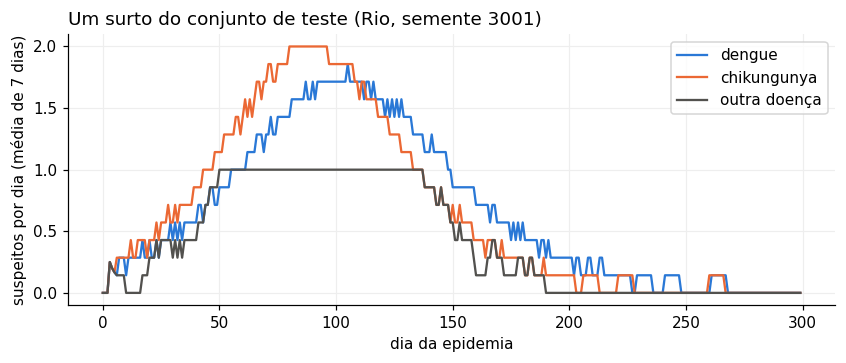

total de suspeitos no episódio: 519  |  por doença: {'chik': 198, 'dengue': 197, 'outro': 124}


In [3]:
from experiments import robustez as R
from dengue_envs.wrappers import make_env

env = make_env(R.config_ambiente("teste_rio"))
obs, info = env.reset(seed=3001)
u = env.unwrapped
casos_mundo = u.world.casedf
serie = casos_mundo.groupby(["t", "disease"]).size().unstack(fill_value=0).reindex(range(u.world.epilength), fill_value=0)
fig, ax = plt.subplots(figsize=(9, 3.2))
for d, nome, cor in ((0, "dengue", AZUL), (1, "chikungunya", LARANJA), (2, "outra doença", CINZA)):
    if d in serie: ax.plot(serie.index, serie[d].rolling(7, min_periods=1).mean(), color=cor, label=nome)
ax.set_xlabel("dia da epidemia"); ax.set_ylabel("suspeitos por dia (média de 7 dias)")
ax.set_title("Um surto do conjunto de teste (Rio, semente 3001)"); ax.legend()
plt.show()
print(f"total de suspeitos no episódio: {len(casos_mundo)}  |  por doença:",
      casos_mundo.disease.map({0: "dengue", 1: "chik", 2: "outro"}).value_counts().to_dict())

### 2.2 Geografia (onde os casos aparecem)

As posições vêm de superfícies de **krigagem ordinária** estimadas a partir das notificações georreferenciadas:
- **Rio de Janeiro 2015–2016** (dengue e chik, coordenadas de residência);
- **Recife 2015–2025**: microdados abertos, sem coordenadas. **Geocodificamos por rua e bairro** contra os polígonos oficiais: 72% na rua informada, 6% em bairro vizinho, 22% no nível do bairro, menos de 1% não localizados.

A pergunta que importa para a decisão não é se cada doença tem focos, mas se **as duas ocupam lugares diferentes**. Medimos isso com a acurácia do classificador de Bayes que só vê a posição: 0,5 = a posição não diz nada; 1 = a posição resolve.

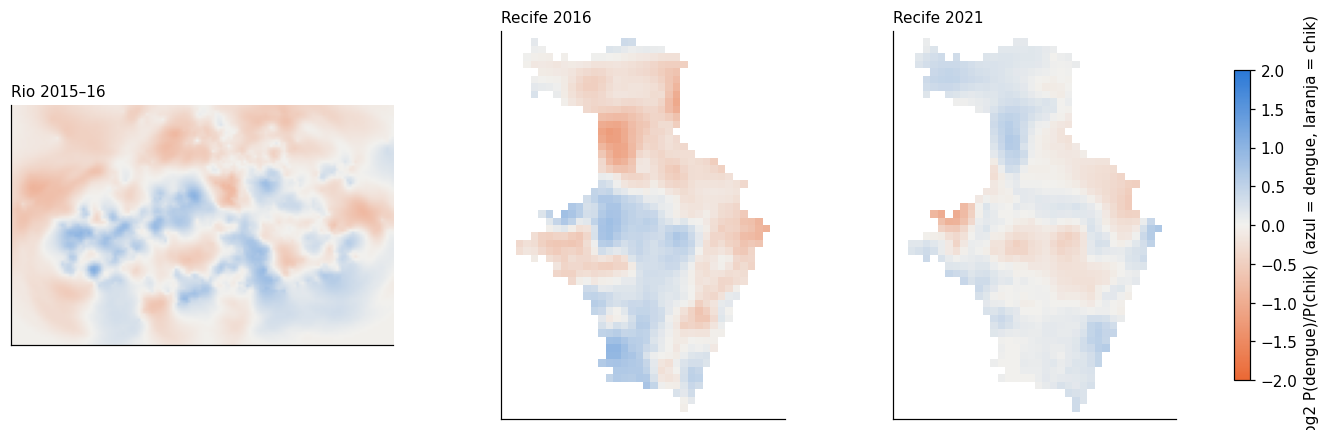

In [4]:
from dengue_envs.data.kriging_generator import load_kriging_surfaces

def painel(ax, s, titulo):
    razao = np.log2(np.clip(s.prob_dengue, 1e-12, None) / np.clip(s.prob_chik, 1e-12, None))
    fora = (s.prob_dengue + s.prob_chik) <= 0
    img = np.ma.masked_where(fora, razao)
    cmap = LinearSegmentedColormap.from_list("cd", [LARANJA, "#f2f1ee", AZUL])
    im = ax.imshow(img, origin="lower", cmap=cmap, vmin=-2, vmax=2)
    ax.set_title(titulo, fontsize=10); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    return im

fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, (arq, tit) in zip(axs, [("results/kriging/rio_2015_2016_kriging_surfaces.npz", "Rio 2015–16"),
                                ("results/kriging/recife_2016_kriging_surfaces.npz", "Recife 2016"),
                                ("results/kriging/recife_2021_kriging_surfaces.npz", "Recife 2021")]):
    im = painel(ax, load_kriging_surfaces(arq), tit)
cb = fig.colorbar(im, ax=axs, shrink=0.8); cb.set_label("log2 P(dengue)/P(chik)  (azul = dengue, laranja = chik)")
plt.show()

In [5]:
rio = pd.read_csv("results/kriging/boot/resumo_rio.csv")
rec = pd.read_csv("results/kriging/boot/resumo_recife.csv")
boot = pd.concat([rio, rec]).groupby(["cidade", "ano"]).acerto_posicao.agg(
    media="mean", ic_lo=lambda s: s.quantile(.025), ic_hi=lambda s: s.quantile(.975)).round(3)
display(Markdown("**Acurácia da posição sozinha, com IC de 95% do bootstrap espacial (20 réplicas por cidade/ano):**"))
boot

**Acurácia da posição sozinha, com IC de 95% do bootstrap espacial (20 réplicas por cidade/ano):**

media  ic_lo  ic_hi
cidade ano                           
recife 2015       0.601  0.597  0.606
       2016       0.556  0.552  0.559
       2017       0.523  0.516  0.532
       2018       0.524  0.518  0.533
       2019       0.568  0.562  0.574
       2020       0.550  0.542  0.558
       2021       0.530  0.528  0.535
       2022       0.525  0.519  0.532
       2023       0.531  0.523  0.542
       2024       0.545  0.537  0.551
       2025       0.564  0.559  0.571
rio    2015-2016  0.541  0.539  0.545

Em **todas as cidades e anos epidêmicos, a posição acerta só 52–57%** (o gerador idealizado dos focos gaussianos chega a 94%). Os focos das duas doenças coincidem, porque ambas seguem onde mora gente e onde está o vetor. **Consequência: o exame é a principal fonte de informação**; o mapa ajuda pouco.

O bootstrap espacial reamostra as notificações e refaz a krigagem (no Recife, também a geocodificação). Ele serve para medir a incerteza (tabela acima) e para dar variedade ao treino (seção 5).

### 2.3 Ciclo de vida de um caso, ações e recompensa

```
suspeito chega (rótulo do médico) ──► agente decide ──► conclui (dengue / chik / outro)  → sai
                                          │
                                          ├─► pede exame de dengue ou de chik ──(5 dias)──► caso volta com o laudo ──► agente decide de novo
                                          ├─► confirmação epidemiológica (vizinhança com casos confirmados)
                                          └─► espera
```

Um caso pode voltar no máximo **2 vezes**; depois disso só ações de conclusão são permitidas (máscara de ação).

| id | ação | custo |
|---|---|---|
| 0 | exame de dengue | 4 |
| 1 | exame de chikungunya | 4 |
| 2 | confirmação epidemiológica | 4 |
| 3 | esperar / não fazer nada | 0 |
| 4 | concluir **dengue** | 0 |
| 5 | concluir **chikungunya** | 0 |
| 6 | concluir **outra doença** | 0 |

| desfecho da conclusão | recompensa |
|---|---|
| acerto | +10 |
| arbovirose errada, ou arbovirose num caso "outro" | −20 |
| concluir "outro" num caso de arbovirose (falso negativo de vigilância) | −30 |
| bônus por concluir um caso investigado (*shaping*) | +2 |
| caso nunca resolvido | −10 |

O custo 4 foi calibrado para que investigar **compense por margem estreita**: é o regime em que escolher *quem* investigar importa.

### 2.4 O que o agente observa

A cada passo o agente decide **um caso**. A observação tem quatro partes:

In [6]:
print(env.observation_space)

Dict('case_coords': Box(0.0, 1.0, (2,), float32), 'context': Box(0.0, 1.0, (16,), float32), 'map': Box(0, 255, (6, 100, 100), uint8), 'mask': MultiBinary(7))


In [7]:
from agents.deepq.agent import observation_from_env
o = observation_from_env(env)
nomes_ctx = (["evidência: concordância laudo × médico", "evidência: força da evidência"]
             + ["rótulo atual: dengue", "rótulo atual: chik", "rótulo atual: outro"]
             + [f"exame dengue: {s}" for s in ("não feito", "neg", "pos", "inconc")]
             + [f"exame chik: {s}" for s in ("não feito", "neg", "pos", "inconc")]
             + ["confirmado epidemiologicamente", "densidade local de confirmados: dengue", "densidade local de confirmados: chik"])
display(Markdown(f"**Caso atual:** id {env.current_case[0]}, coordenadas normalizadas {o['case_coords'].round(3)}"))
display(pd.DataFrame({"feature": nomes_ctx, "valor": o["context"].round(3)}))
print("máscara de ações permitidas:", o["mask"])

**Caso atual:** id 0, coordenadas normalizadas [0.065 0.79 ]

,feature,valor
0,evidência: concordância laudo × médico,0.5
1,evidência: força da evidência,0.0
2,rótulo atual: dengue,1.0
3,rótulo atual: chik,0.0
4,rótulo atual: outro,0.0
5,exame dengue: não feito,1.0
6,exame dengue: neg,0.0
7,exame dengue: pos,0.0
8,exame dengue: inconc,0.0
9,exame chik: não feito,1.0


máscara de ações permitidas: [1 1 1 1 1 1 1]


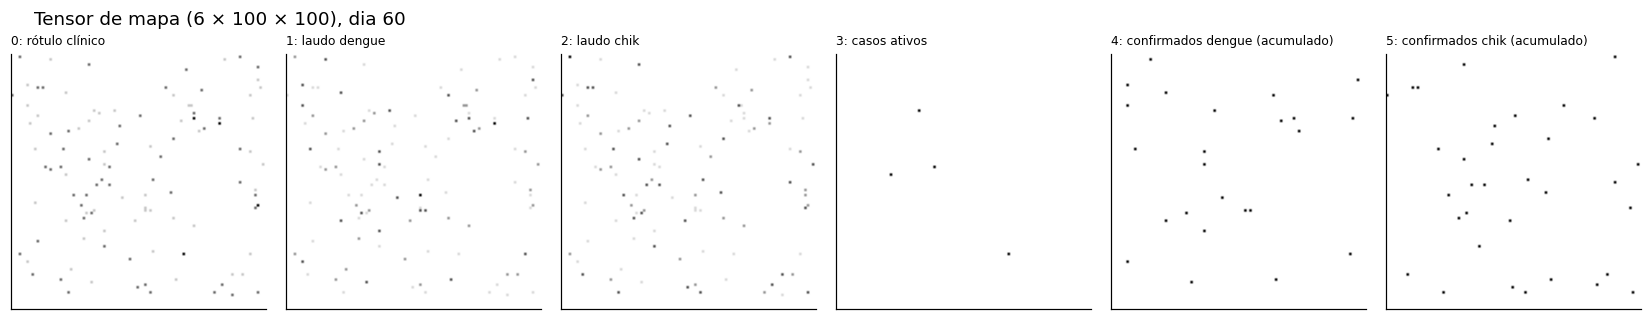

In [8]:
canais = ["0: rótulo clínico", "1: laudo dengue", "2: laudo chik", "3: casos ativos",
          "4: confirmados dengue (acumulado)", "5: confirmados chik (acumulado)"]
# Avança uns 60 dias com a regra clínica, só para o mapa ter conteúdo.
from experiments.evaluate import _make_runner
regra = _make_runner("sequencial_clinico", {})
while u.t < 60:
    env.step(regra.choose_action(env))
m = observation_from_env(env)["map"]
fig, axs = plt.subplots(1, 6, figsize=(15, 2.8), constrained_layout=True)
for i, ax in enumerate(axs):
    ax.imshow(m[i].T, origin="lower", cmap="Greys", vmin=0, vmax=max(1, m[i].max()))
    ax.set_title(canais[i], fontsize=8); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.suptitle(f"Tensor de mapa (6 × 100 × 100), dia {u.t}", x=0.02, ha="left")
plt.show()

- **mapa** 6×100×100: o que a vigilância sabe, espacialmente (rótulos, laudos, casos ativos, confirmados).
- **coordenadas** do caso atual (2).
- **contexto** (16): evidência acumulada sobre a competência do médico (nível do episódio) + atributos do caso (rótulo, estado dos dois exames, confirmação epidemiológica, densidade local de confirmados).
- **máscara** (7): ações permitidas.

A densidade local de confirmados exclui o próprio caso — sem isso ela devolveria o laudo do caso com outro nome (medimos: acertaria 99,6%).

## 3. Um episódio visto de perto

Registramos cada decisão do agente C treinado no Rio e da regra clínica nos mesmos 30 surtos de teste (`python -m experiments.analise_casos`). Abaixo, a trajetória de alguns casos reais do surto 3001: cada linha é uma decisão.

In [9]:
dec = pd.read_csv("results/analise_casos/teste_rio__rio_C_s45.csv.gz")
ACOES = {0: "exame dengue", 1: "exame chik", 2: "confirma epi", 3: "espera", 4: "conclui DENGUE", 5: "conclui CHIK", 6: "conclui OUTRO"}
DOE = {0: "dengue", 1: "chik", 2: "outro"}; LAU = {0: "–", 1: "neg", 2: "pos", 3: "inconc"}
d = dec[dec.seed == 3001].copy()
d["acao"] = d.acao.map(ACOES); d["médico diz"] = d.suspeita.map(DOE); d["verdade"] = d.real.map(DOE)
d["laudo dengue"] = d.testd.map(LAU); d["laudo chik"] = d.testc.map(LAU)
exemplos = []
for alvo in [(0, 0), (0, 1), (0, 2), (1, 1), (2, 2)]:   # (rótulo do médico, verdade)
    ids = d[(d.suspeita == alvo[0]) & (d.real == alvo[1])].caso.unique()
    if len(ids): exemplos.append(ids[0])
d[d.caso.isin(exemplos)][["caso", "dia", "rodada", "médico diz", "verdade", "laudo dengue", "laudo chik", "acao"]]

,caso,dia,rodada,médico diz,verdade,laudo dengue,laudo chik,acao
0,0,3,0,dengue,dengue,–,–,exame dengue
1,1,3,0,chik,chik,–,–,exame chik
2,2,3,0,dengue,outro,–,–,exame dengue
5,0,9,1,dengue,dengue,pos,–,conclui DENGUE
6,1,9,1,chik,chik,–,pos,conclui CHIK
7,2,9,1,dengue,outro,neg,–,exame chik
15,2,15,2,dengue,outro,neg,neg,conclui OUTRO
30,19,23,0,outro,outro,–,–,exame chik
48,19,29,1,outro,outro,–,inconc,conclui OUTRO
106,56,44,0,dengue,chik,–,–,exame dengue


Leitura: o agente pede o exame da doença que o médico suspeita; se vier positivo, conclui; se vier negativo, pede o outro exame e conclui com os dois laudos. Quando o médico diz "outra doença", o agente geralmente conclui direto, sem exame (seção 6.4).

### 3.1 Onde o agente age: mapas de um surto

Cada ponto é um suspeito do surto 3001, na posição onde foi notificado, sobre a superfície de probabilidade da cidade (fundo cinza: mais escuro = mais casos esperados).

- **forma** = quantos exames o caso recebeu: ▲ nenhum, ● um, ■ dois;
- **cor** = se a conclusão final acertou: <span style="color:#2a78d6">**azul = acertou**</span>, <span style="color:#e34948">**vermelho = errou**</span>.

As posições são recuperadas refazendo o surto com a mesma semente (o mundo é determinístico dada a semente); as decisões vêm dos registros de `results/analise_casos/`.

In [10]:
from dengue_envs.data.kriging_generator import probability_to_env_grid

CASOS = pd.read_csv("results/analise_casos/casos.csv.gz", low_memory=False)
ACERTO, ERRO = AZUL, "#e34948"
FORMAS = {0: ("^", "nenhum exame"), 1: ("o", "1 exame"), 2: ("s", "2 exames")}

def surto(teste, seed):
    # Refaz o surto e devolve posições (grid 400x400) e o fundo de probabilidade.
    e = make_env(R.config_ambiente(teste)); e.reset(seed=seed)
    w = e.unwrapped.world
    if hasattr(w, "prob_dengue"):
        fundo = w.prob_dengue + w.prob_chik
    else:  # gerador idealizado: densidade dos próprios casos, suavizada
        from scipy.ndimage import gaussian_filter
        h = np.histogram2d(w.casedf.x, w.casedf.y, bins=w.size, range=[[0, w.size], [0, w.size]])[0]
        fundo = gaussian_filter(h, 12) + 1e-6
    pos = w.casedf[["x", "y", "disease"]].rename_axis("caso").reset_index()
    e.close()
    return pos, fundo

def mapa(ax, teste, agente, seed=3001, titulo=None, filtro=None):
    pos, fundo = surto(teste, seed)
    c = CASOS[(CASOS.agente == agente) & (CASOS.teste == teste) & (CASOS.seed == seed)].merge(pos, on="caso")
    if filtro is not None:
        c = c[filtro(c)]
    ax.imshow(np.log(np.clip(fundo.T, 1e-9, None)), origin="lower", cmap="Greys", alpha=.55)
    for n, (mk, _) in FORMAS.items():
        for ok, cor in ((True, ACERTO), (False, ERRO)):
            s = c[(c.n_exames.clip(upper=2) == n) & (c.acertou == ok)]
            ax.scatter(s.x, s.y, marker=mk, s=22, c=cor, edgecolors="white", linewidths=.4, alpha=.9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(titulo or f"{agente} em {teste}", fontsize=10)
    ax.text(0.01, -0.07, f"{len(c)} casos · {int(c.n_exames.sum())} exames · acurácia {c.acertou.mean():.3f}",
            transform=ax.transAxes, fontsize=8.5)
    return c

def legenda(fig):
    from matplotlib.lines import Line2D
    h = [Line2D([], [], marker=mk, ls="", color=CINZA, label=nome) for mk, nome in FORMAS.values()]
    h += [Line2D([], [], marker="o", ls="", color=ACERTO, label="acertou"),
          Line2D([], [], marker="o", ls="", color=ERRO, label="errou")]
    fig.legend(handles=h, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.06), frameon=False)

**Mesmo surto do Rio, três políticas.** A regra testa todo mundo; o agente C do Rio quase só deixa sem exame os casos que o médico rotulou como "outra doença"; o agente A (GAE padrão) quase não testa e erra muito.

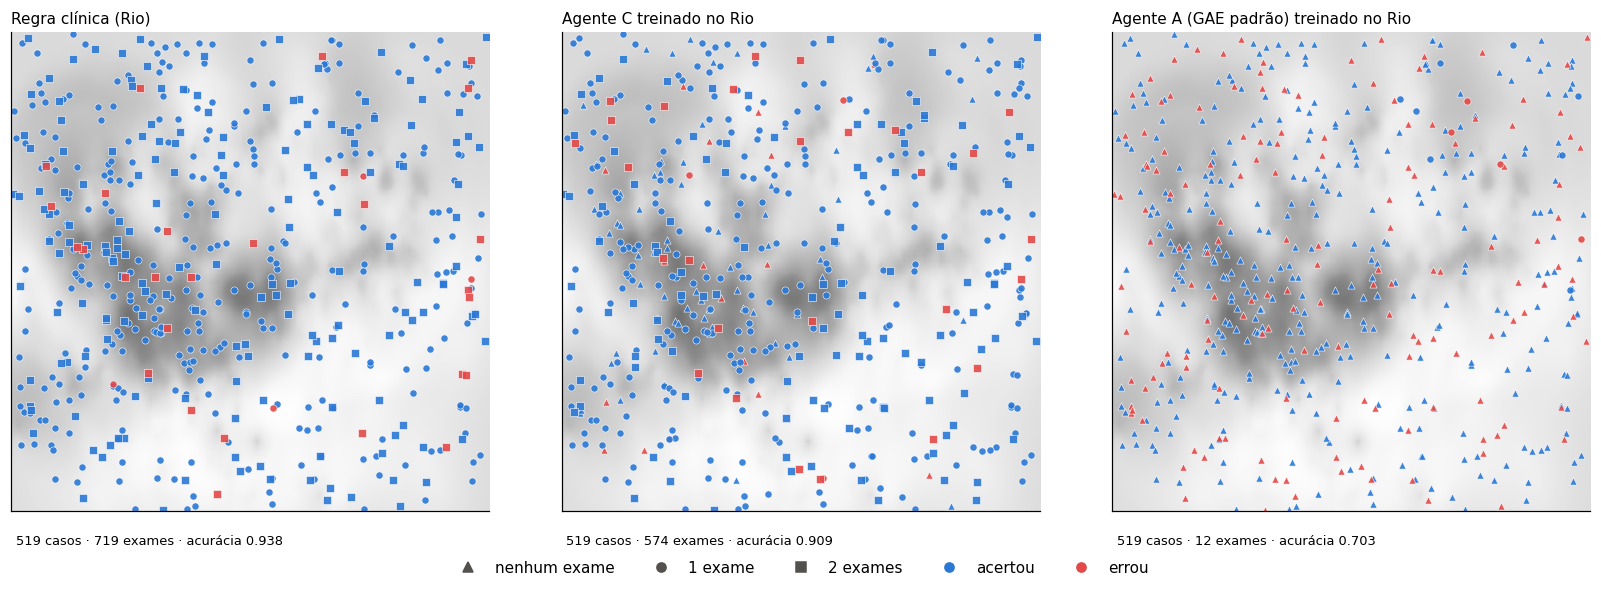

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
mapa(axs[0], "teste_rio", "sequencial_clinico", titulo="Regra clínica (Rio)")
mapa(axs[1], "teste_rio", "rio_C_s45", titulo="Agente C treinado no Rio")
# O agente A não entra na análise por caso completa; este surto foi registrado à parte
# (results/analise_casos/_extra/, gerado com experiments.analise_casos.roda_unidade).
from experiments.analise_casos import por_caso
extra = por_caso(pd.read_csv("results/analise_casos/_extra/teste_rio__rio_A_s45.csv.gz"))
extra["politica"] = "rio_A"
CASOS = pd.concat([CASOS[CASOS.agente != "rio_A_s45"], extra], ignore_index=True)
mapa(axs[2], "teste_rio", "rio_A_s45", titulo="Agente A (GAE padrão) treinado no Rio")
legenda(fig); plt.show()

**O agente C do Rio, separado pelo rótulo do médico.** Os casos rotulados "outra doença" (direita) quase nunca são testados — é daí que vem a economia de exames, e também a maior parte dos erros extras.

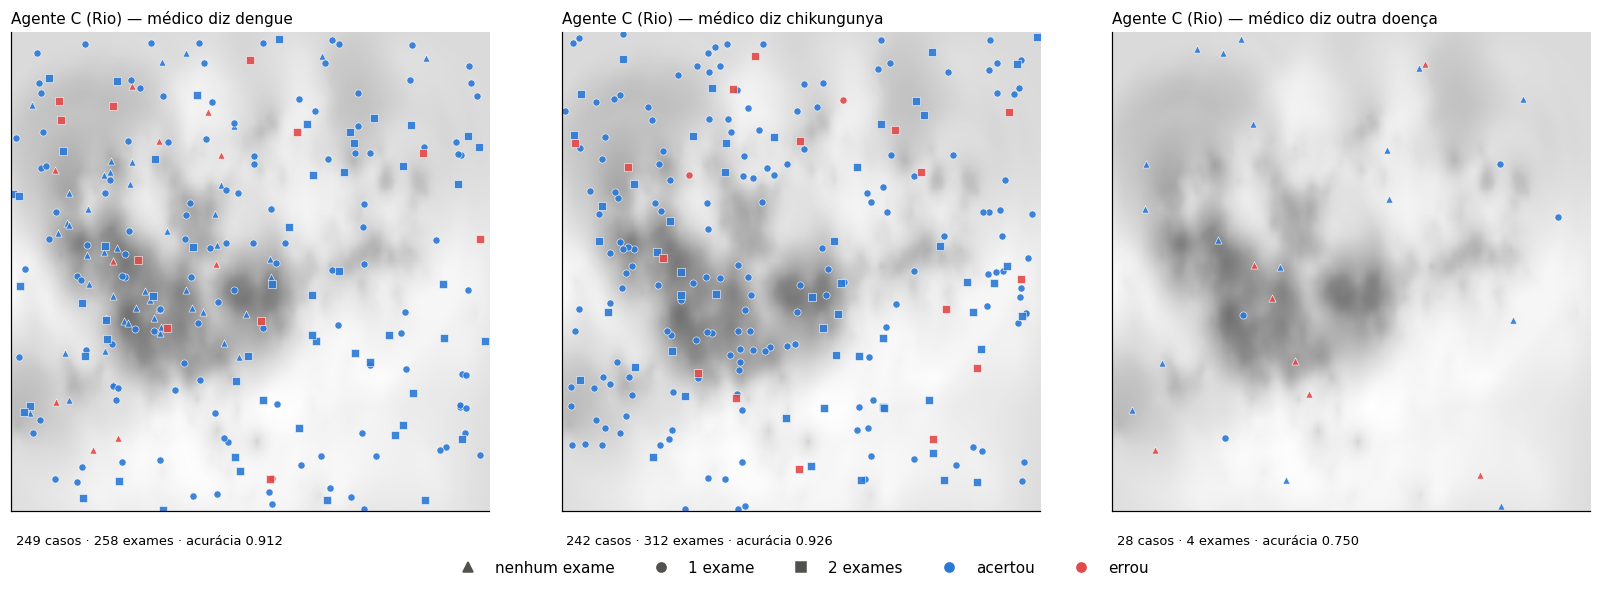

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, (rot, nome) in zip(axs, [(0, "médico diz dengue"), (1, "médico diz chikungunya"), (2, "médico diz outra doença")]):
    mapa(ax, "teste_rio", "rio_C_s45", titulo=f"Agente C (Rio) — {nome}", filtro=lambda c, r=rot: c.suspeita == r)
legenda(fig); plt.show()

**Transferência e o cenário idealizado.**
- À esquerda, o agente do Rio num surto do Recife 2016, cidade que ele nunca viu: mesmo padrão de exames. Os pontos **fora do contorno da cidade** são os casos "outra doença" do ambiente original, espalhados pelo grid inteiro — é o defeito do simulador discutido na seção 6.3.
- À direita, o agente treinado no gerador idealizado, onde a posição revela a doença. Os círculos marcam os focos de dengue (azul, embaixo à esquerda) e de chikungunya (laranja, em cima à direita), e a linha tracejada é a fronteira entre eles. Ele **deixa sem exame os casos longe da fronteira**, onde a posição basta, e testa os que estão perto dela (tabela abaixo).

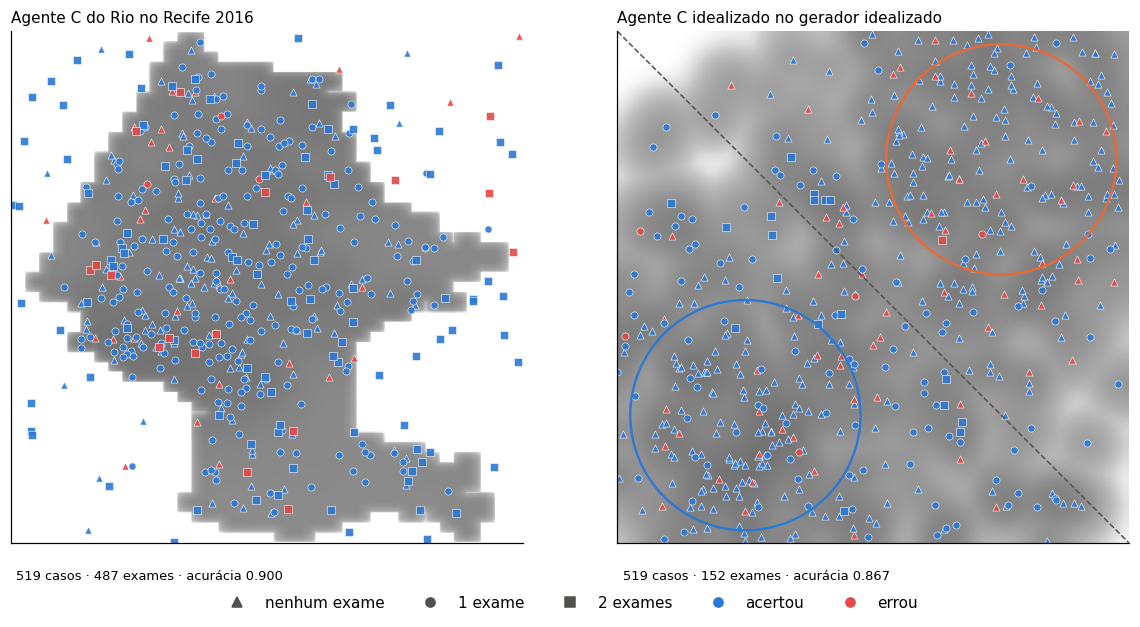

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5.3), constrained_layout=True)
mapa(axs[0], "teste_recife_2016", "rio_C_s45", titulo="Agente C do Rio no Recife 2016")
mapa(axs[1], "teste_sintetico", "sintetico_C_s45", titulo="Agente C idealizado no gerador idealizado")
for (cx, cy), cor in (((100, 100), AZUL), ((300, 300), LARANJA)):
    axs[1].add_patch(plt.Circle((cx, cy), 90, fill=False, ls="-", lw=1.5, color=cor))
axs[1].plot([0, 400], [400, 0], ls="--", color=CINZA, lw=1)
axs[1].set_xlim(0, 400); axs[1].set_ylim(0, 400)
legenda(fig); plt.show()

In [14]:
# Agente idealizado, surtos 3001-3010: quanto mais longe da fronteira entre os focos, menos exames.
c = CASOS[(CASOS.agente == "sintetico_C_s45") & (CASOS.teste == "teste_sintetico") & (CASOS.seed <= 3010)]
pos = pd.concat([surto("teste_sintetico", s)[0].assign(seed=s) for s in range(3001, 3011)])
c = c.merge(pos, on=["seed", "caso"])
margem = (np.hypot(c.x - 100, c.y - 100) - np.hypot(c.x - 300, c.y - 300)).abs()
c["distância da fronteira (células)"] = pd.cut(margem, [0, 60, 120, 200, 600], include_lowest=True)
c.groupby("distância da fronteira (células)").agg(
    casos=("n_exames", "size"), sem_exame=("n_exames", lambda s: (s == 0).mean()), acuracia=("acertou", "mean")).round(3)

,casos,sem_exame,acuracia
distância da fronteira (células),,,
"(-0.001, 60.0]",759,0.282,0.895
"(60.0, 120.0]",795,0.387,0.888
"(120.0, 200.0]",1211,0.644,0.872
"(200.0, 600.0]",2172,0.826,0.873


In [15]:
# Resumo numérico dos mapas acima: exames e acertos por situação (surto 3001).
res = []
for teste, ag in [("teste_rio", "sequencial_clinico"), ("teste_rio", "rio_C_s45"), ("teste_rio", "rio_A_s45"),
                  ("teste_recife_2016", "rio_C_s45"), ("teste_sintetico", "sintetico_C_s45")]:
    c = CASOS[(CASOS.agente == ag) & (CASOS.teste == teste) & (CASOS.seed == 3001)]
    res.append({"agente": ag, "teste": teste, "casos": len(c), "sem exame": int((c.n_exames == 0).sum()),
                "1 exame": int((c.n_exames == 1).sum()), "2 exames": int((c.n_exames >= 2).sum()),
                "acertos": int(c.acertou.sum()), "erros": int((~c.acertou.astype(bool)).sum()),
                "erros sem exame": int(((c.n_exames == 0) & ~c.acertou.astype(bool)).sum())})
pd.DataFrame(res)

,agente,teste,casos,sem exame,1 exame,2 exames,acertos,erros,erros sem exame
0,sequencial_clinico,teste_rio,519,0,319,200,487,32,0
1,rio_C_s45,teste_rio,519,82,300,137,472,47,17
2,rio_A_s45,teste_rio,519,507,12,0,365,154,150
3,rio_C_s45,teste_recife_2016,519,155,241,123,467,52,30
4,sintetico_C_s45,teste_sintetico,519,386,114,19,450,69,63


## 4. O agente

### 4.1 Arquitetura

Ator e crítico com o mesmo tipo de tronco (sem compartilhar pesos):
- **mapa** → 3 camadas convolucionais → *adaptive average pooling* para 64×6×6 → projeção linear para 128;
- **coordenadas** → MLP pequena;
- **contexto** (16) → MLP → 128;
- concatenação → cabeça do **ator** (128 → 7 logits, com a máscara aplicando −∞ às ações proibidas) e do **crítico** (128 → 1 valor).

In [16]:
from agents.ppo.agent import PPOAgent
ag = PPOAgent.load("results/ppo_v6/rio_C_s45/policy_final.pth", env)
print(ag.actor)
n = sum(p.numel() for p in ag.actor.parameters())
print(f"\nparâmetros do ator: {n:,}")

DengueActor(
  (trunk): DengueTrunk(
    (map_encoder): Sequential(
      (0): Conv2d(6, 16, kernel_size=(8, 8), stride=(4, 4))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
      (3): ReLU()
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
      (5): ReLU()
      (6): AdaptiveAvgPool2d(output_size=(6, 6))
      (7): Flatten(start_dim=1, end_dim=-1)
    )
    (map_proj): Sequential(
      (0): Linear(in_features=2304, out_features=128, bias=True)
      (1): ReLU()
    )
    (coord_encoder): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
    )
    (context_encoder): Sequential(
      (0): Linear(in_features=16, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
    )
  )
  (net): Sequential(
    (0): Linear(in_features=320, out_features=128, bi

In [17]:
# O que o agente "pensa" sobre o caso atual: probabilidade de cada ação.
import torch
o = observation_from_env(env)
with torch.no_grad():
    logits, _ = ag.actor({k: np.asarray(v)[None] for k, v in o.items()})
probs = torch.softmax(logits, -1).numpy()[0]
cid = env.current_case[0]
linha = u.obs_cases.loc[cid]
display(Markdown(f"Caso {cid}, dia {u.t}: médico diz **{DOE[int(linha['disease'])]}**, laudos: dengue {LAU[int(linha['testd'])]}, chik {LAU[int(linha['testc'])]}"))
pd.Series(probs, index=[ACOES[i] for i in range(7)]).round(3).to_frame("probabilidade")

Caso 106, dia 60: médico diz **dengue**, laudos: dengue –, chik –

,probabilidade
exame dengue,0.821
exame chik,0.112
confirma epi,0.010
espera,0.031
conclui DENGUE,0.025
conclui CHIK,0.000
conclui OUTRO,0.001


### 4.2 Por que o PPO padrão falha, e o crédito por caso

No PPO padrão, a vantagem (GAE) encadeia passos **consecutivos** da trajetória. Aqui, passos consecutivos são decisões sobre **pacientes diferentes**: o valor de pedir um exame para o paciente X precisa atravessar dezenas de decisões sobre outros pacientes até chegar ao laudo de X. Medimos:

| retorno usado | correlação com a utilidade de um exame |
|---|---|
| retorno padrão (γ = 0,99 sobre passos) | **−0,02** |
| retorno ao longo da linha do tempo do próprio caso | **0,99** |

**PPO com crédito por caso (braço C)**: cada transição carrega (episódio, caso, dia, parcela da recompensa que pertence ao caso). A vantagem é calculada **ao longo da linha do tempo de cada paciente**, com desconto elevado ao número de **dias** entre decisões:

$$\text{disc}_j = \gamma^{\,d_{j+1}-d_j},\qquad \delta_j = r^{\text{caso}}_j + \text{disc}_j\,V(s_{j+1}) - V(s_j),\qquad \hat A_j = \delta_j + \text{disc}_j\,\lambda\,\hat A_{j+1}.$$

Nada muda no ambiente nem na recompensa total (testes automatizados verificam que as parcelas por caso somam a recompensa do episódio, e que intercalar decisões de outros casos não altera a vantagem de X). É análogo à atribuição de crédito em sistemas multiagente, com cada paciente como um agente. Código: `agents/ppo/credit.py`.

| braço | vantagem | observação |
|---|---|---|
| **A** | GAE padrão | igual à do C |
| **C** | GAE por caso, em dias | igual à do A |

## 5. Conjuntos de treino e protocolo de avaliação

### 5.1 Hiperparâmetros (iguais para todos os treinos)

In [18]:
tr = yaml.safe_load(open("experiments/configs/train/v6/rio_C_s45.yaml", encoding="utf-8"))
pd.Series({k: v for k, v in tr["train"].items()}).to_frame("valor")

,valor
epochs,10
step_per_epoch,30000
step_per_collect,2000
repeat_per_collect,10
batch_size,256
lr,0.0003
gamma,0.99
gae_lambda,0.95
eps_clip,0.2
ent_coef,0.02


300 mil passos por treino (10 épocas × 30 mil), 8 ambientes paralelos, recompensas escaladas por 0,1 só no treino. Um treino leva ~3 h em CPU.

### 5.2 Onde cada agente treina

Os resultados finais usam **5 sementes de treino** (45–49) por grupo e braço, todos no **ambiente corrigido** (seção 6.3). A cada episódio o ambiente sorteia uma superfície do conjunto de treino e aplica uma transformação rígida (identidade, 180°, espelhos) às duas doenças juntas — muda *onde* estão as coisas, não *quão difícil* é distingui-las.

In [19]:
treinos = pd.DataFrame([
    ("final", "sintetico", "A e C", 5, "gerador idealizado (dois focos gaussianos; posição acerta 94%)", "300 mil"),
    ("final", "rio", "A e C", 5, "20 réplicas do bootstrap espacial do Rio 2015–16", "300 mil"),
    ("final", "recifesup", "A e C", 5, "20 réplicas × 8 anos do Recife (2017–20, 2022–25), corrigido; 2016 e 2021 ficam para teste", "300 mil"),
    ("final", "mistosup", "A e C", 5, "1/3 sintético + 1/3 Rio + 1/3 Recife, corrigido", "600 mil"),
    ("final", "riocusto2 / riocusto8", "C", 3, "Rio com custo do exame 2 ou 8 (varredura de custo)", "300 mil"),
    ("diagnóstico", "recife", "A e C", 3, "Recife ORIGINAL (casos 'outro' no grid todo) — revelou o defeito", "300 mil"),
    ("diagnóstico", "recifepos", "C", 3, "Recife com escala, rotação e posição sorteadas (tentativa que piorou)", "300 mil"),
    ("diagnóstico", "riofis / recifefis", "C", 3, "Rio e Recife em escala física comum (200 m/célula)", "300 mil"),
], columns=["rodada", "grupo", "braços", "sementes", "superfícies de treino", "passos"])
treinos

,rodada,grupo,braços,sementes,superfícies de treino,passos
0,final,sintetico,A e C,5,gerador idealizado (dois focos gaussianos; pos...,300 mil
1,final,rio,A e C,5,20 réplicas do bootstrap espacial do Rio 2015–16,300 mil
2,final,recifesup,A e C,5,"20 réplicas × 8 anos do Recife (2017–20, 2022–...",300 mil
3,final,mistosup,A e C,5,"1/3 sintético + 1/3 Rio + 1/3 Recife, corrigido",600 mil
4,final,riocusto2 / riocusto8,C,3,Rio com custo do exame 2 ou 8 (varredura de cu...,300 mil
5,diagnóstico,recife,A e C,3,Recife ORIGINAL (casos 'outro' no grid todo) —...,300 mil
6,diagnóstico,recifepos,C,3,"Recife com escala, rotação e posição sorteadas...",300 mil
7,diagnóstico,riofis / recifefis,C,3,Rio e Recife em escala física comum (200 m/cél...,300 mil


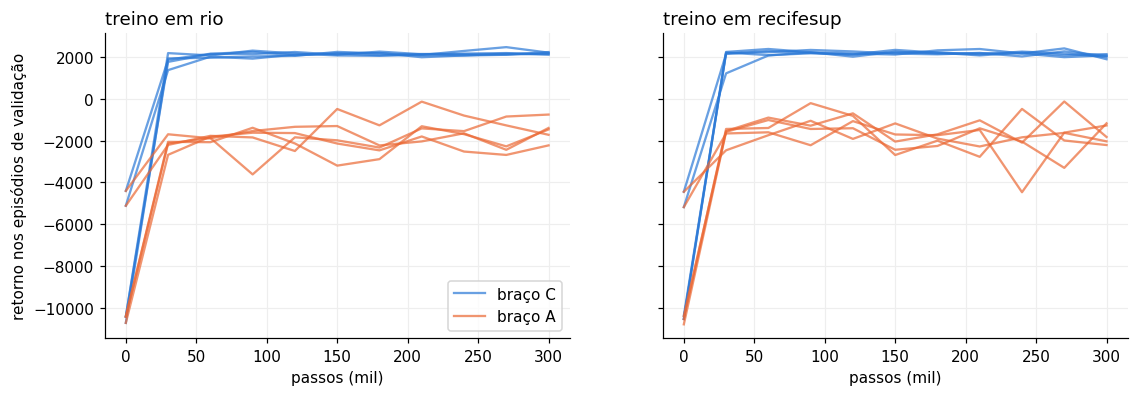

In [20]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def curva(run):
    pts = {}
    for f in sorted(glob.glob(f"results/ppo_v6/{run}/logs/events.out.tfevents.*")):
        e = EventAccumulator(f); e.Reload()
        if "test/returns_stat/mean" not in e.Tags()["scalars"]: continue
        passos = {s.step: s.value for s in e.Scalars("test/env_step")}
        for s in e.Scalars("test/returns_stat/mean"):
            pts[passos.get(s.step, s.step)] = s.value
    return pd.Series(pts).sort_index()

fig, axs = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, grupo in zip(axs, ["rio", "recifesup"]):
    for braco, cor in (("C", AZUL), ("A", LARANJA)):
        for s in (45, 46, 47, 48, 49):
            c = curva(f"{grupo}_{braco}_s{s}")
            if len(c): ax.plot(c.index / 1e3, c.values / 0.1, color=cor, alpha=.7, label=f"braço {braco}" if s == 45 else None)
    ax.set_title(f"treino em {grupo}"); ax.set_xlabel("passos (mil)")
axs[0].set_ylabel("retorno nos episódios de validação"); axs[0].legend()
plt.show()

### 5.3 Protocolo de avaliação

- Todo agente treinado e toda regra fixa são avaliados em **4 geografias de teste**, sempre nas superfícies **originais** (nunca nas réplicas de treino): Rio 2015–16, **Recife 2016 e 2021 (fora do treino do Recife)** e o gerador idealizado.
- **30 surtos pareados inéditos** por teste (sementes 3001–3030): todos os agentes veem exatamente os mesmos surtos.
- **Conjunto de confirmação:** a matriz e os custos 6 e 8 são refeitos em **30 surtos novos (4001–4030)**, nunca olhados durante o desenvolvimento (seção 6.7).
- **Varreduras** no Rio, sem retreino: custo do exame, sensibilidade do RT-PCR e acurácia do médico (seção 6.6).
- **Bootstrap hierárquico pareado** (10 mil réplicas): reamostra sementes de treino e, dentro delas, surtos; os surtos são compartilhados entre os braços, então as diferenças são pareadas. Reportamos média com IC de 95% e $P(X > Y)$.

**Regras fixas de referência** (o que se consegue sem aprender):

| regra | o que faz |
|---|---|
| clínica | nunca testa; vale o rótulo do médico |
| testa uma vez | um exame de dengue por caso |
| testa duas vezes | os dois exames sempre |
| sequencial, dengue primeiro | dengue; se não der positivo, chik |
| **sequencial clínica** | começa pelo exame da doença que o médico suspeita — melhor regra escrita a priori |
| sequencial, confia no "outro"\* | a clínica, mas sem exame quando o médico diz "outra doença" |

\* Escrita **depois** da análise por caso do agente (seção 6.4).

Comandos: `python -m experiments.fila --v7` (treinos), `python -m experiments.avaliacao_v7 --workers 10` (avaliação), `--analisa` (bootstrap) e `--conjunto confirmacao` (surtos novos).

## 6. Resultados

### 6.1 Ambiente completo, no Rio de Janeiro

In [21]:
b = pd.read_csv(V7 / "bracos_teste_rio.csv")
nomes = {"C|rio": "C: crédito por caso (treinado no Rio)", "A|rio": "A: GAE padrão (treinado no Rio)",
         "sequencial_confia_outro": "regra: sequencial, confia no 'outro'*", "sequencial_clinico": "regra: sequencial clínica",
         "sequencial": "regra: sequencial, dengue primeiro", "testtwice": "regra: testa duas vezes",
         "testonce": "regra: testa uma vez", "clinical": "regra: só o médico"}
linhas = []
for k, nome in nomes.items():
    r = b[b.braco == k].set_index("metrica")
    f = lambda m, d=0: f"{r.loc[m, 'media']:.{d}f} [{r.loc[m, 'media_lo']:.{d}f}, {r.loc[m, 'media_hi']:.{d}f}]"
    linhas.append((nome, f("recompensa"), f("acuracia", 3), f("exames")))
pd.DataFrame(linhas, columns=["política", "recompensa [IC 95%]", "acurácia", "exames por episódio"])

,política,recompensa [IC 95%],acurácia,exames por episódio
0,C: crédito por caso (treinado no Rio),"2168 [2042, 2290]","0.935 [0.927, 0.940]","651 [621, 679]"
1,A: GAE padrão (treinado no Rio),"-1743 [-2299, -1193]","0.580 [0.544, 0.616]","63 [27, 103]"
2,"regra: sequencial, confia no 'outro'*","2205 [2089, 2316]","0.939 [0.935, 0.943]","661 [634, 687]"
3,regra: sequencial clínica,"2149 [2043, 2254]","0.941 [0.938, 0.945]","699 [669, 728]"
4,"regra: sequencial, dengue primeiro","1799 [1700, 1897]","0.937 [0.933, 0.941]","772 [749, 794]"
5,regra: testa duas vezes,"1144 [1064, 1228]","0.937 [0.933, 0.941]","931 [899, 963]"
6,regra: testa uma vez,"407 [323, 488]","0.763 [0.757, 0.768]","466 [449, 481]"
7,regra: só o médico,"-368 [-436, -299]","0.551 [0.515, 0.588]","0 [0, 0]"


In [22]:
c = pd.read_csv(V7 / "comparacoes_teste_rio.csv")
c = c[c.metrica.isin(["recompensa", "exames", "acuracia"]) & c.x.isin(["C|rio", "sequencial_confia_outro"])
      & c.y.isin(["A|rio", "sequencial_clinico", "sequencial_confia_outro"])]
c[["x", "y", "metrica", "diferenca", "dif_lo", "dif_hi", "p_x_melhor"]].round(3)

,x,y,metrica,diferenca,dif_lo,dif_hi,p_x_melhor
0,sequencial_confia_outro,sequencial_clinico,recompensa,56.067,-25.603,138.333,0.517
4,C|rio,A|rio,recompensa,3910.720,3394.732,4437.595,1.000
5,C|rio,sequencial_clinico,recompensa,19.093,-89.294,121.084,0.527
6,C|rio,sequencial_confia_outro,recompensa,-36.973,-138.204,56.481,0.487
13,sequencial_confia_outro,sequencial_clinico,acuracia,-0.002,-0.006,0.002,0.433
17,C|rio,A|rio,acuracia,0.355,0.318,0.391,1.000
18,C|rio,sequencial_clinico,acuracia,-0.006,-0.014,0.000,0.343
19,C|rio,sequencial_confia_outro,acuracia,-0.004,-0.012,0.002,0.420
26,sequencial_confia_outro,sequencial_clinico,exames,-38.333,-42.968,-33.533,0.000
30,C|rio,A|rio,exames,588.193,540.571,631.548,1.000


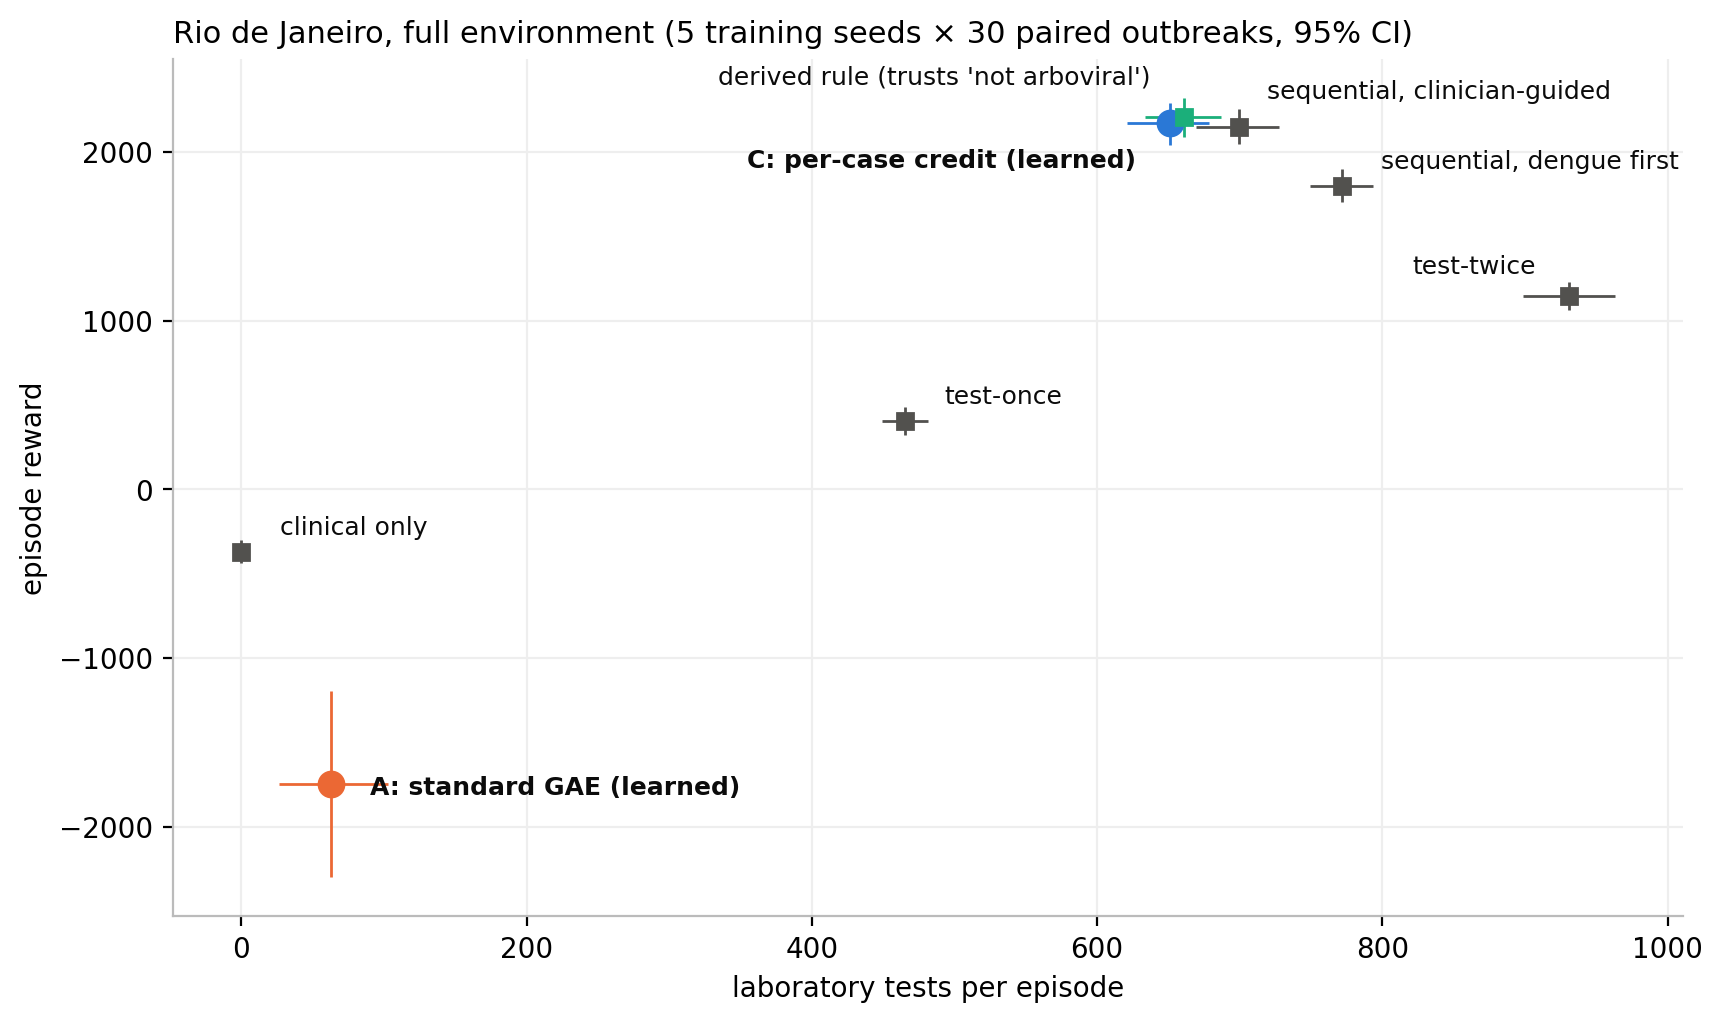

In [23]:
display(Image("Artigo/img/fig_policies_full.png", width=750))

**Leitura:**
- O PPO padrão (A) **colapsa**: pede quase nenhum exame e fica abaixo de não fazer nada. C × A = **+3911** [+3395, +4438].
- O agente com crédito por caso (C) **empata com a melhor regra escrita a priori** (+19 [−89, +121]), com a mesma acurácia e **49 exames a menos por surto (−7%)**. Ninguém disse a ele a ordem dos exames nem o quanto o médico é confiável.

### 6.2 Transferência entre geografias

Cada célula: recompensa do agente C treinado na linha, menos a da regra clínica, no teste da coluna (IC 95%; negrito = IC exclui zero). Ambiente corrigido, 5 sementes.

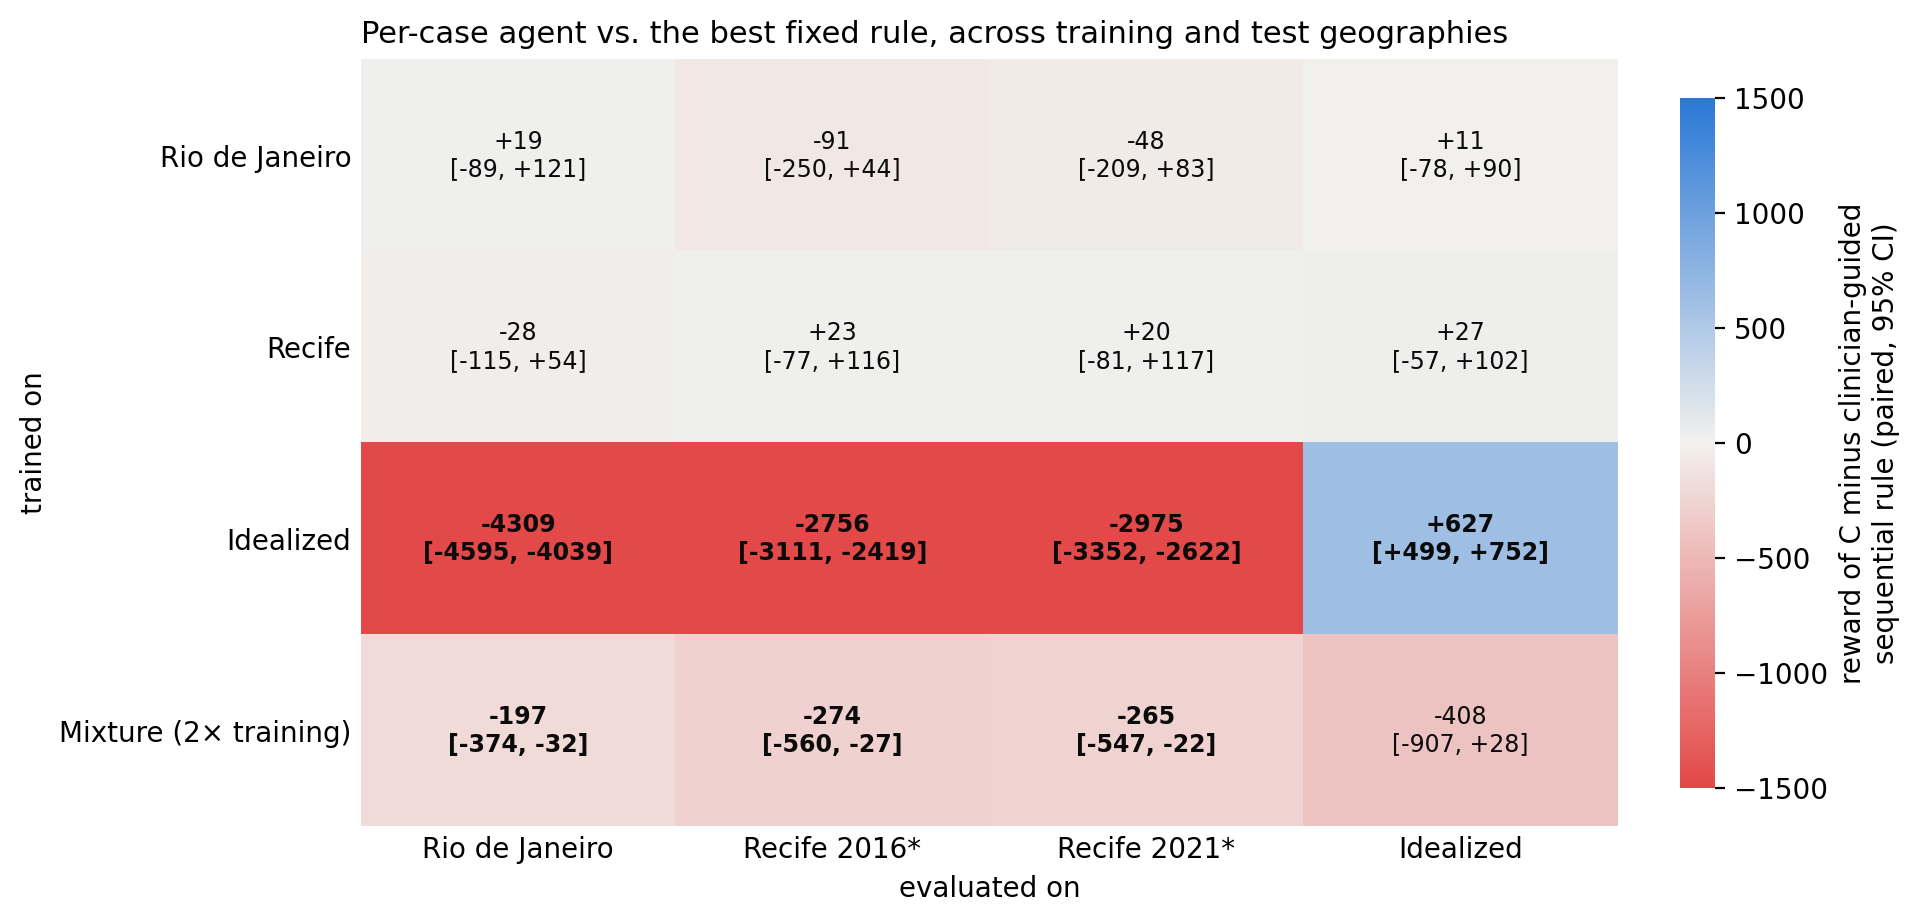

In [24]:
display(Image("Artigo/img/fig_transfer.png", width=850))

**Leitura:**
- **O crédito por caso vence o GAE padrão nas 16 combinações** treino × teste (de +1215 a +4275; $P(C>A)$ entre 0,95 e 1,00).
- **Rio ↔ Recife transfere nos dois sentidos:** os agentes das duas cidades empatam com a regra nas duas. O do Recife é o mais estável (desvio entre sementes de 21 no Rio). Nos surtos novos, o do Rio fica um pouco abaixo no Recife (~7–8%; seção 6.7).
- **Onde a posição informa (idealizado), aprender vence a regra** (+627, com 62% menos exames), mas essa política **não transfere** para cidades reais, onde a posição não informa.
- **A mistura de geografias não funciona:** mesmo com o dobro de treino, fica abaixo da regra nas três cidades reais (−197 a −274) e é instável entre sementes. Uma política só teria de agir de modos opostos.

### 6.3 O defeito do simulador e a correção

**Diagnóstico por ablação** (zerando entradas sem retreinar): o agente do Rio ignora mapa, posição e vizinhança. O do Recife colapsa sem a posição (+2135 → −4631) e transfere *melhor* para o Rio sem o mapa (+464 → +1514). Ele estava usando uma pista espacial que só o Recife tinha.

**A pista era um defeito:** os casos "outro" caíam uniformes no grid **inteiro**, mas o município do Recife ocupa só 44% do grid. Um caso fora da cidade era "outro" com certeza — cerca de 14% dos casos, identificáveis pela posição. No Rio a superfície cobre o grid inteiro, então a pista não existe.

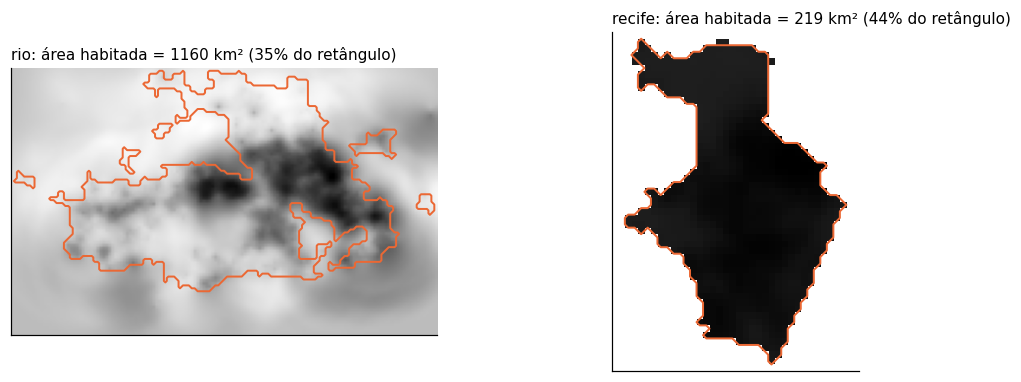

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, cid, arq in ((axs[0], "rio", "results/kriging/rio_2015_2016_kriging_surfaces.npz"),
                     (axs[1], "recife", "results/kriging/recife_2016_kriging_surfaces.npz")):
    s = load_kriging_surfaces(arq); m = np.load(f"results/kriging/{cid}_mask.npz")["mask"]
    ax.imshow(np.log(np.clip(s.prob_dengue + s.prob_chik, 1e-9, None)), origin="lower", cmap="Greys")
    ax.contour(m, levels=[.5], colors=LARANJA, linewidths=1.3)
    ax.set_title(f"{cid}: área habitada = {m.sum() * 0.25:.0f} km² ({m.mean():.0%} do retângulo)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.show()

**Correção:** a área habitada das duas cidades é definida pela **mesma regra**, a partir das próprias notificações (células de 500 m com pelo menos 2 notificações de qualquer agravo, fechadas e sem buracos). No Recife a regra recupera o polígono oficial quase exatamente (875 × 879 células); no Rio dá 1.160 km² (o município tem 1.200 km²). Os casos "outro" passam a cair só ali (`python -m dengue_envs.data.build_masks`).

A figura abaixo mostra a **primeira rodada** (3 sementes): à esquerda, o simulador original, em que o agente do Recife falhava; à direita, a tentativa de **escala física comum** (200 m por célula nas duas cidades). O resultado com a correção é a matriz da seção 6.2.

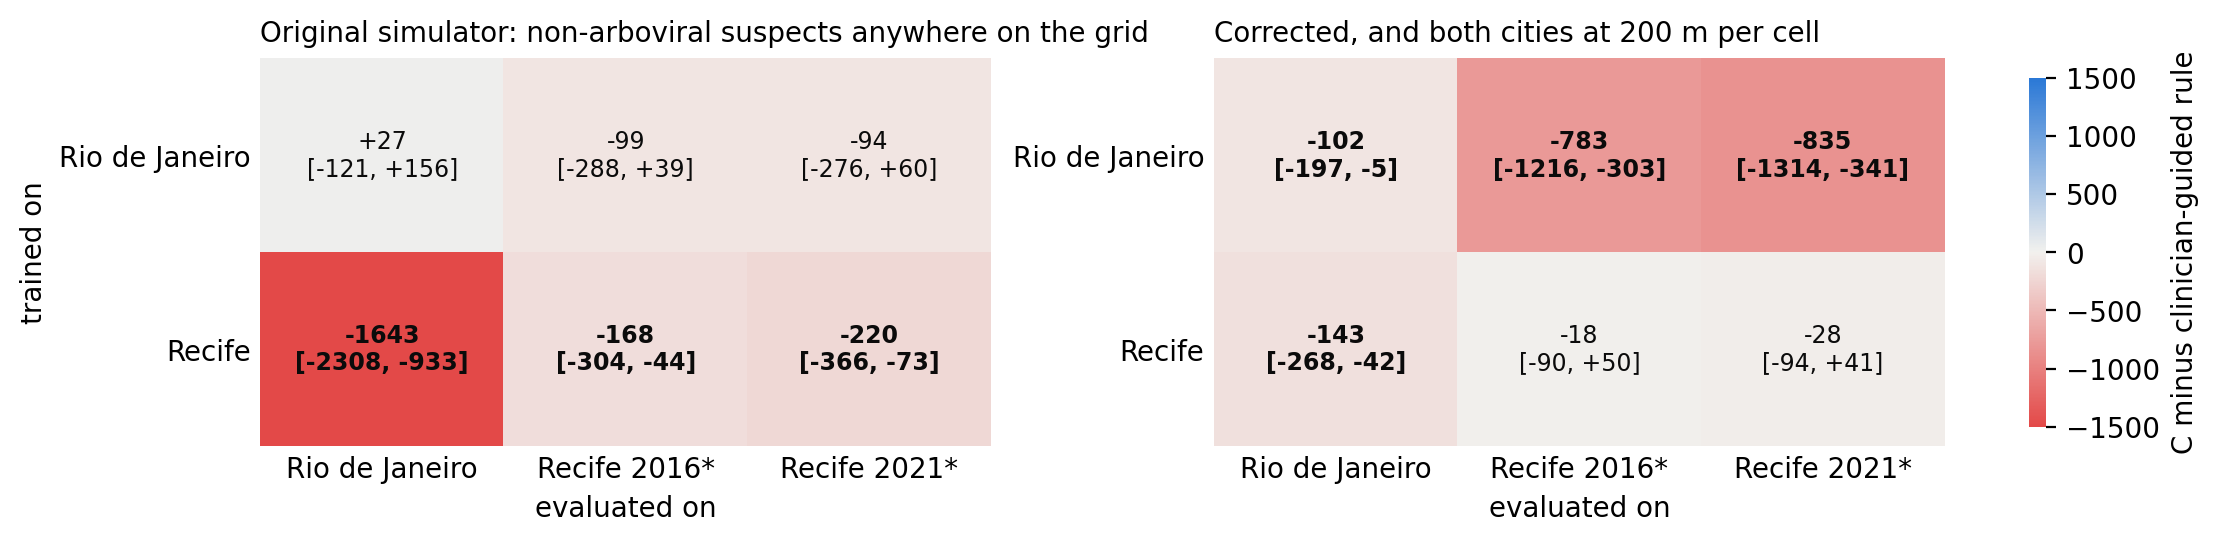

In [26]:
display(Image("Artigo/img/fig_transfer_corrected.png", width=900))

**Leitura:**
- **Esquerda — simulador original:** o agente do Recife fica abaixo da regra até nos próprios anos guardados (−168, −220) e desaba no Rio (−1643, desvio entre sementes de 722). Com a correção (seção 6.2 e tabela abaixo), empata em tudo, com desvio de 21.
- **Direita — escala física (200 m/célula):** o Recife passa a transferir para o Rio, mas o Rio **falha no Recife**. A causa é medida: cada surto tem o mesmo número de casos independentemente do tamanho da cidade; o Recife, 5× menor, fica 5× mais denso, e a feature de densidade local satura em 83% das decisões (37% no Rio, 0,3% no ambiente original). Para ser fisicamente consistente, o número de casos também precisa escalar com a população.

**Lição:** o que parecia aprendizado ruim era um artefato do simulador. A avaliação agregada não distinguia um do outro; as ablações e o teste entre cidades localizaram o problema.

In [27]:
sup = []
for t in ("teste_rio", "teste_recife_2016_sup", "teste_recife_2021_sup"):
    cc = pd.read_csv(V7 / f"comparacoes_{t}.csv")
    cc = cc[(cc.metrica == "recompensa") & (cc.y == "sequencial_clinico") & cc.x.isin(["C|rio", "C|recifesup"])]
    sup += [(r.x.replace("C|", "treinado em "), t, f"{r.diferenca:+.0f} [{r.dif_lo:+.0f}, {r.dif_hi:+.0f}]") for r in cc.itertuples()]
pd.DataFrame(sup, columns=["agente", "teste", "C − regra clínica"]).pivot(index="agente", columns="teste", values="C − regra clínica")

teste,teste_recife_2016_sup,teste_recife_2021_sup,teste_rio
agente,,,
treinado em recifesup,"+23 [-77, +116]","+20 [-81, +117]","-28 [-115, +54]"
treinado em rio,"-91 [-250, +44]","-48 [-209, +83]","+19 [-89, +121]"


### 6.4 O que o agente aprendeu, caso a caso

A recompensa agregada diz que o agente é tão bom quanto a regra, não *como*. Registramos ~35 mil decisões por agente e teste e resumimos por caso.

In [28]:
casos = pd.read_csv("results/analise_casos/casos.csv.gz", low_memory=False)
sel = casos[((casos.politica == "regra") & (casos.teste == "teste_rio")) | ((casos.politica == "rio_C") & (casos.teste == "teste_rio"))
            | ((casos.politica == "sintetico_C") & (casos.teste == "teste_sintetico"))]
tab = sel.groupby(["politica", "suspeita_n"]).agg(
    casos=("n_exames", "size"), exames_por_caso=("n_exames", "mean"),
    sem_exame=("n_exames", lambda s: (s == 0).mean()), dois_exames=("n_exames", lambda s: (s >= 2).mean()),
    acuracia=("acertou", "mean")).round(3)
tab.rename_axis(["política", "rótulo do médico"])

casos  exames_por_caso  sem_exame  dois_exames  acuracia
política    rótulo do médico                                                          
regra       chik               6816            1.462      0.000        0.462     0.943
            dengue             6549            1.506      0.000        0.506     0.936
            outro               603            1.912      0.000        0.912     0.959
rio_C       chik              20232            1.447      0.001        0.448     0.940
            dengue            19802            1.455      0.029        0.484     0.934
            outro              1870            0.059      0.941        0.000     0.848
sintetico_C chik              20517            0.537      0.562        0.099     0.893
            dengue            19551            0.579      0.514        0.092     0.891
            outro              1836            0.443      0.561        0.004     0.927

In [29]:
neg = sel[(sel.laudo1 == "neg") & (sel.suspeita_n != "outro")]
tested = sel[(sel.n_exames >= 1) & (sel.suspeita_n != "outro")]
pd.DataFrame({
    "1º exame = suspeita do médico": tested.groupby("politica").primeiro_eh_suspeita.apply(lambda s: s.astype(bool).mean()),
    "pede o 2º exame após um negativo": neg.groupby("politica").n_exames.apply(lambda s: (s >= 2).mean()),
}).round(3)

,1º exame = suspeita do médico,pede o 2º exame após um negativo
politica,,
regra,1.000,1.000
rio_C,0.993,1.000
sintetico_C,0.468,0.464


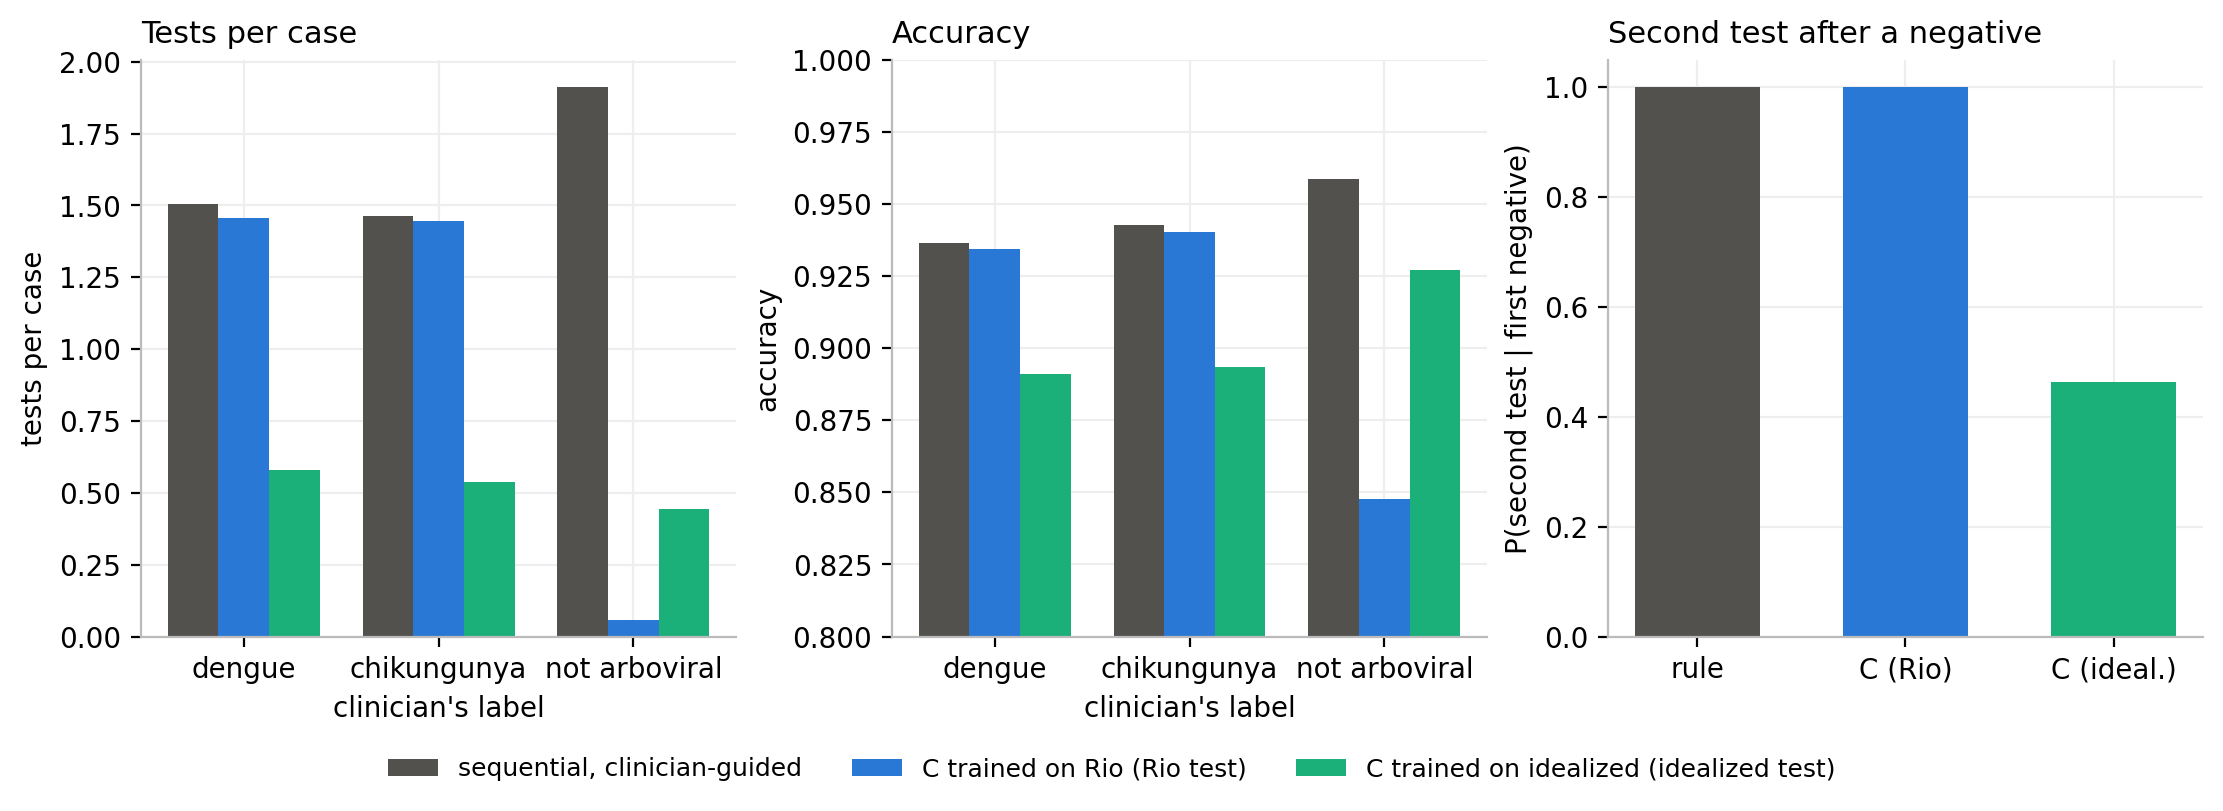

In [30]:
display(Image("Artigo/img/fig_cases.png", width=950))

**Leitura:**
- Para suspeitas de dengue ou chik, o agente do Rio faz **exatamente o que a regra faz**: exame da doença suspeita primeiro (99%) e o segundo exame depois de **todo** negativo (≈100%). Ele **não** escolhe quem precisa do segundo exame.
- A economia de exames vem de outro lugar: ele **não testa 94% dos casos que o médico rotula como "outra doença"** (4,3% dos casos, dos quais 84% realmente são outra doença). A acurácia nesses casos cai de 0,96 para 0,85, mas ele economiza 1,9 exame por caso.
- **Escrevendo isso como regra fixa** ("sequencial, confia no 'outro'"), obtemos uma regra **tão boa quanto a do especialista com 38 exames a menos** (+56 [−26, +138], não significativo) e **melhor quando o exame é caro** (custo 8: +209). O agente empata com ela no Rio (−37 [−138, +56]).
- O agente do cenário idealizado, onde a posição informa, faz outra coisa: testa só 46% dos casos e pula metade dos segundos exames — e supera todas as regras (+562 sobre a regra derivada).

**A análise caso a caso transformou o que o agente aprendeu numa regra simples e frugal.** Ninguém disse ao agente que o rótulo "outra doença" do médico era confiável o bastante para agir; ele descobriu pela recompensa.

### 6.5 O 2º exame é sempre ótimo?

Depois de um primeiro negativo, concluir a classe $c$ na hora vale $10\,p_c + e_c(1-p_c)$ ($e_c = -30$ para "outro", $-20$ para uma arbovirose). Pedir o segundo exame vale o que a regra de fato obtém depois dele, menos o custo. Estimamos $p_c$ para cada caso com regressão logística multinomial (validação cruzada) sobre tudo o que o agente observa (`python -m experiments.analise_casos --limiar`):

In [31]:
pd.read_csv("results/analise_casos/tab_limiar_segundo_exame.csv")

,teste,casos,valor_2o_exame,posterior_max_mediana,posterior_max_p99,frac_parar_melhor,ganho_max_por_caso
0,teste_rio,6202,2.17,0.522,0.700,0.0040,2.67
1,teste_recife_2016_sup,6136,2.10,0.537,0.720,0.0062,2.87
2,teste_recife_2021_sup,6136,2.10,0.539,0.714,0.0055,2.31
3,teste_recife_2016,6202,2.17,0.655,0.875,0.1682,5.29
4,teste_recife_2021,6202,2.17,0.656,0.862,0.1608,5.63


**Leitura:** depois de um negativo, a dúvida entre "a outra arbovirose" e "outra doença" fica **perto de 50/50 para quase todo caso** (probabilidade máxima mediana 0,52 no Rio). Concluir na hora só compensaria em 0,4% dos negativos no Rio (0,6% no Recife corrigido), com ganho de menos de 1 ponto por surto. **O agente está certo em não selecionar**: neste ambiente não há informação por caso que separe os negativos. No Recife original (com o defeito), 16–17% dos casos passariam do limiar — o mesmo artefato de novo.

### 6.6 Sensibilidade aos parâmetros simulados

Custo do exame, sensibilidade do RT-PCR e acurácia do médico são parâmetros do simulador, não medidas. Avaliamos os agentes do Rio (treinados com custo 4) e as regras variando cada um, sem retreinar. Cada ponto é a diferença para a regra do especialista, com IC 95%.

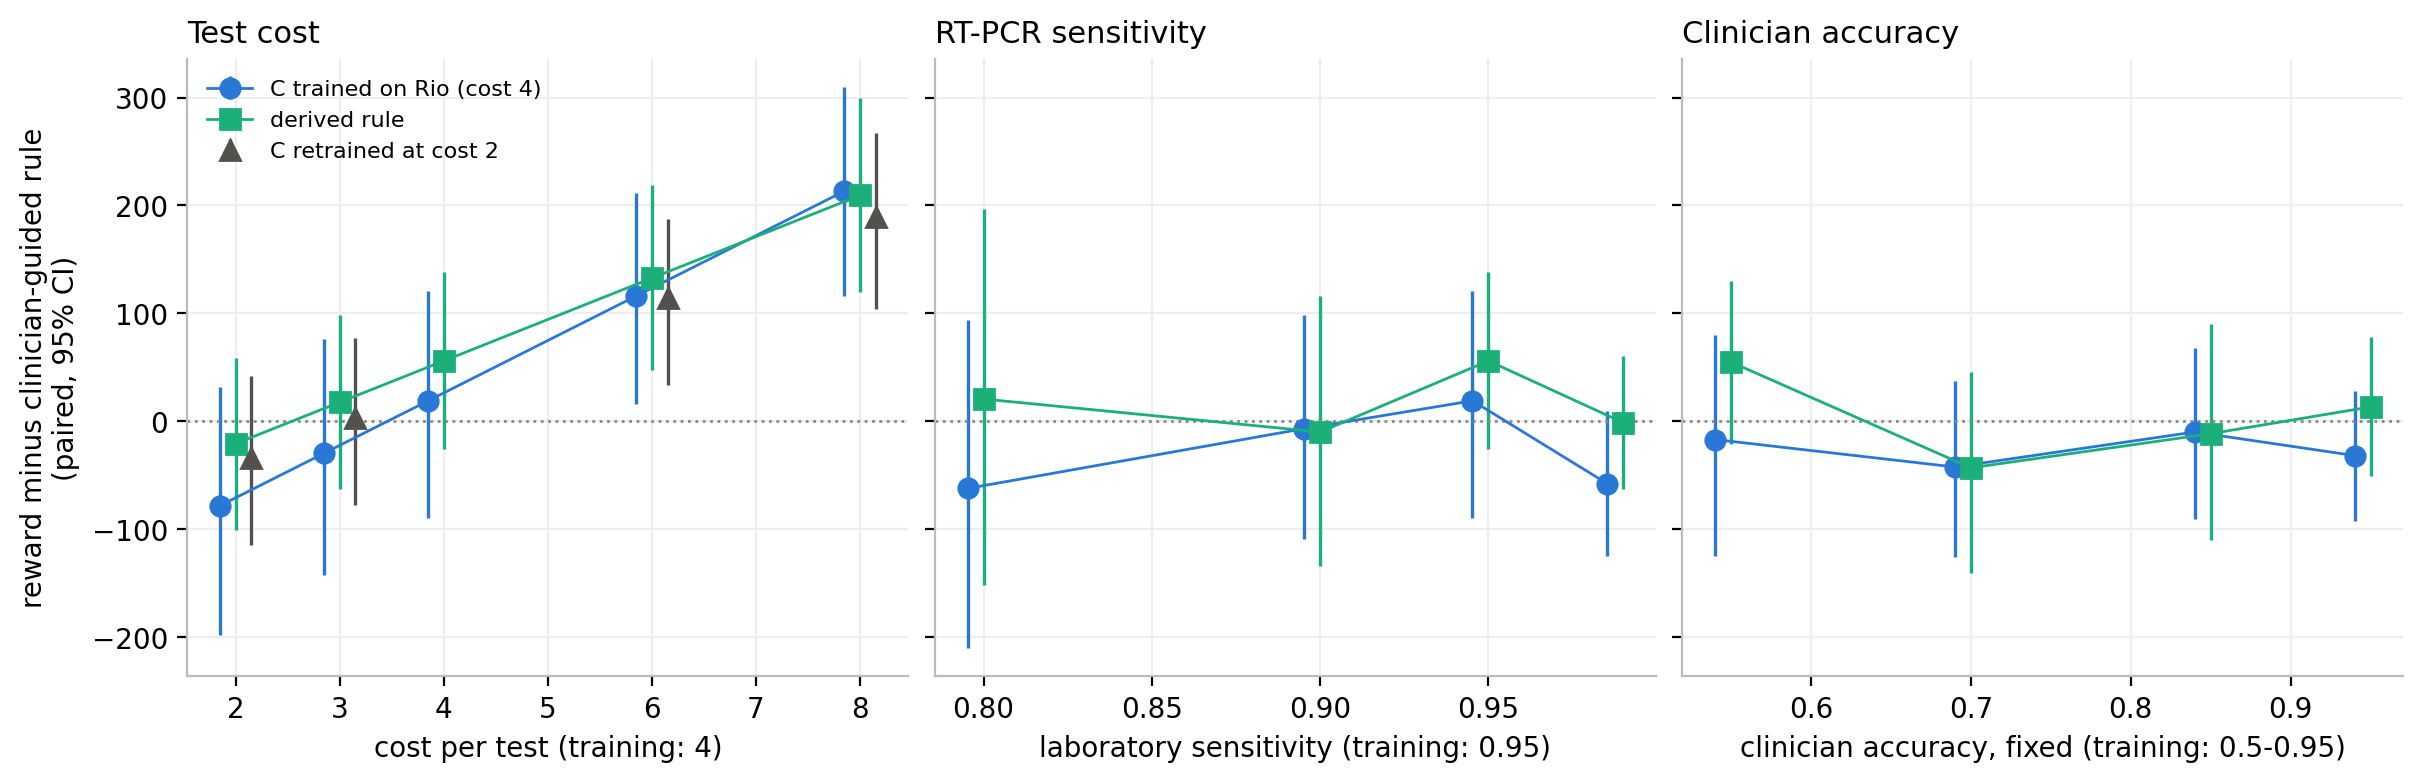

In [32]:
display(Image("Artigo/img/fig_sensitivity.png", width=950))

In [33]:
conds = ["teste_rio__custo2", "teste_rio__custo3", "teste_rio", "teste_rio__custo6", "teste_rio__custo8",
         "teste_rio__sens0.80", "teste_rio__sens0.90", "teste_rio__sens0.99",
         "teste_rio__medico0.55", "teste_rio__medico0.70", "teste_rio__medico0.85", "teste_rio__medico0.95"]
def dif(cc, x):
    r = cc[(cc.x == x) & (cc.y == "sequencial_clinico") & (cc.metrica == "recompensa")]
    return f"{r.diferenca.iloc[0]:+.0f} [{r.dif_lo.iloc[0]:+.0f}, {r.dif_hi.iloc[0]:+.0f}]" if len(r) else ""
linhas = []
for t in conds:
    cc = pd.read_csv(V7 / f"comparacoes_{t}.csv")
    nome = t.replace("teste_rio__", "") if "__" in t else "padrão (custo 4, sens. 0,95)"
    linhas.append((nome, dif(cc, "C|rio"), dif(cc, "sequencial_confia_outro"), dif(cc, "C|riocusto2"), dif(cc, "C|riocusto8")))
pd.DataFrame(linhas, columns=["condição", "agente do Rio − regra", "regra derivada − regra",
                              "retreinado custo 2 − regra", "retreinado custo 8 − regra"])

,condição,agente do Rio − regra,regra derivada − regra,retreinado custo 2 − regra,retreinado custo 8 − regra
0,custo2,"-78 [-198, +32]","-21 [-100, +58]","-34 [-115, +42]","-4489 [-5461, -3681]"
1,custo3,"-29 [-143, +76]","+18 [-63, +98]","+3 [-77, +77]","-3896 [-4779, -3158]"
2,"padrão (custo 4, sens. 0,95)","+19 [-89, +121]","+56 [-26, +138]",,
3,custo6,"+116 [+16, +212]","+133 [+47, +219]","+115 [+33, +188]","-2114 [-2764, -1573]"
4,custo8,"+213 [+116, +309]","+209 [+120, +300]","+189 [+104, +267]","-927 [-1427, -500]"
5,sens0.80,"-62 [-210, +94]","+21 [-151, +196]",,
6,sens0.90,"-7 [-109, +99]","-10 [-134, +116]",,
7,sens0.99,"-58 [-125, +10]","-1 [-63, +61]",,
8,medico0.55,"-17 [-125, +80]","+55 [-21, +130]",,
9,medico0.70,"-42 [-126, +38]","-43 [-141, +46]",,


**Leitura:**
- **Sensibilidade do RT-PCR (0,80–0,99) e acurácia do médico (0,55–0,95):** o agente empata com a regra em todas as condições, sempre com ~45 exames a menos. As recompensas mudam muito com esses parâmetros, mas agente e regra mudam juntos.
- **Custo do exame:** como o agente e a regra derivada economizam exames, a vantagem cresce com o preço do exame. Empatam com custo 2–4 e vencem com custo 6 e 8.
- **Retreinar com custo 8 falha:** o agente quase não testa e fica pior que não fazer nada. Com esse custo, não testar ninguém vence qualquer política que teste; não há mais problema de alocação.

### 6.7 Confirmação em surtos novos

A regra derivada e a correção do simulador foram desenhadas olhando os surtos 3001–3030. Para tirar esse viés de seleção, refizemos a matriz e os custos 6 e 8 em **30 surtos novos (4001–4030)**, que nunca tinham sido usados.

In [34]:
def comp(base, t, x, y="sequencial_clinico"):
    cc = pd.read_csv(base / f"comparacoes_{t}.csv")
    r = cc[(cc.x == x) & (cc.y == y) & (cc.metrica == "recompensa")]
    return f"{r.diferenca.iloc[0]:+.0f} [{r.dif_lo.iloc[0]:+.0f}, {r.dif_hi.iloc[0]:+.0f}]" if len(r) else ""
itens = [("Rio no Rio", "teste_rio", "C|rio"), ("Rio no Recife 2016", "teste_recife_2016_sup", "C|rio"),
         ("Rio no Recife 2021", "teste_recife_2021_sup", "C|rio"), ("Recife no Rio", "teste_rio", "C|recifesup"),
         ("Recife no Recife 2016", "teste_recife_2016_sup", "C|recifesup"),
         ("Idealizado no idealizado", "teste_sintetico", "C|sintetico"), ("Mistura no Rio", "teste_rio", "C|mistosup"),
         ("Regra derivada (Rio)", "teste_rio", "sequencial_confia_outro"),
         ("Regra derivada, custo 6", "teste_rio__custo6", "sequencial_confia_outro"),
         ("Regra derivada, custo 8", "teste_rio__custo8", "sequencial_confia_outro"),
         ("Agente do Rio, custo 8", "teste_rio__custo8", "C|rio")]
pd.DataFrame([(n, comp(V7, t, x), comp(CONFIRMA, t, x)) for n, t, x in itens],
             columns=["comparação (− regra do especialista)", "surtos 3001–3030", "surtos novos 4001–4030"])

,comparação (− regra do especialista),surtos 3001–3030,surtos novos 4001–4030
0,Rio no Rio,"+19 [-89, +121]","-9 [-109, +89]"
1,Rio no Recife 2016,"-91 [-250, +44]","-177 [-373, -8]"
2,Rio no Recife 2021,"-48 [-209, +83]","-150 [-332, -5]"
3,Recife no Rio,"-28 [-115, +54]","-66 [-158, +29]"
4,Recife no Recife 2016,"+23 [-77, +116]","-85 [-189, +16]"
5,Idealizado no idealizado,"+627 [+499, +752]","+605 [+501, +702]"
6,Mistura no Rio,"-197 [-374, -32]","-299 [-556, -88]"
7,Regra derivada (Rio),"+56 [-26, +138]","+8 [-90, +109]"
8,"Regra derivada, custo 6","+133 [+47, +219]","+88 [-14, +193]"
9,"Regra derivada, custo 8","+209 [+120, +300]","+167 [+61, +276]"


**Leitura:** quase tudo se repete nos surtos novos — C vence A em todas as combinações, o agente do Rio empata no Rio, o do Recife empata nos quatro testes, o idealizado vence só no idealizado, a mistura continua abaixo da regra e a regra derivada continua tão boa quanto a do especialista com menos exames, e melhor com custo 8. **Duas ressalvas:** o agente do Rio fica um pouco abaixo da regra no Recife (−150 a −177, ~7–8%), e a vantagem da regra derivada com custo 6 não se reproduz (só com custo 8).

## 7. Conclusões e próximos passos

**O que está estabelecido**
1. **Nos dados reais, a posição quase não revela a doença** (52–57% em todas as cidades e anos, IC ±0,01). O exame é a principal fonte de informação.
2. **O PPO padrão não aprende a usar exames** porque o valor de um exame se dilui entre decisões intercaladas sobre outros pacientes. **O crédito por caso resolve**, sem mudar ambiente nem recompensa, e vence em todas as 16 combinações de treino e teste.
3. **Nas cidades reais, o agente empata com a melhor regra escrita a priori com 7% menos exames**, de forma robusta ao custo do exame, à sensibilidade do RT-PCR e à acurácia do médico, e também em surtos novos. A leitura caso a caso das decisões produz uma **regra fixa frugal**. Onde a posição informa, ele supera todas as regras.
4. **Transferência:** Rio ↔ Recife transferem depois de corrigido um artefato do simulador, que as ablações localizaram (com uma perda pequena, ~7–8%, do Rio para o Recife nos surtos novos). O idealizado não transfere para cidades reais, e a mistura de geografias não funciona.

**Limitações**
- 5 sementes de treino por braço (ainda pouco para o nível superior do bootstrap).
- Treinar com exame muito caro (custo 8) colapsa.
- Sem heterogeneidade por caso (sintomas, dias de sintoma), por isso selecionar o segundo exame não faz sentido neste ambiente.
- Escassez modelada por custo, não por capacidade diária do laboratório.
- Escala física consistente exige também número de casos proporcional à população.

**Próximos passos**
- Anos novos do Rio (dados da Fiocruz) como teste fora do treino.
- Número de casos proporcional à população na escala física.
- Calibrar acerto do médico, sensibilidade por dia de coleta e sintomas com os microdados do Recife.
- Heterogeneidade por caso e capacidade diária do laboratório, para que *quem testar duas vezes* vire uma decisão real.

**Onde está cada coisa:** artigo em `Artigo/main.tex` (PDF em `Artigo/main.pdf`); figuras reproduzíveis em `experiments/figuras_artigo.py`; resultados em `results/v6_avaliacao/` e `results/analise_casos/`.